# Fibonacci Retracement — a quantitative teardown 🔬
### 5% ZigZag swings · realised-retracement binning · Fib-vs-placebo two-sample *t* · same-bars coin placebo · threshold\u00d7horizon grid · costs · two synthetic controls

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Fib_levels_special%3F: Not_Supported](https://img.shields.io/badge/Fib_levels_special%3F-Not_Supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We mark swings with a ZigZag, measure each pullback's realised retracement, bet the trend resumes, and race the **Fibonacci** depths against a **placebo** of arbitrary fractions in the same band.

> ⚠️ **Not investment advice.** Real data: yfinance daily OHLC for 8 broad index/ETF tapes (as-of 2026-06-30, combined fp `11844738632b`); the offline core and controls run on deterministic synthetic worlds. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fibonacci_retracement import data, strategy as st

ASOF = "2026-06-30"
PCT, HORIZON, TOL = 0.05, 20, 0.025

def load_tapes():
    """Cache-first basket of daily OHLC tapes, trimmed to the as-of date (empty offline)."""
    bk = data.load_basket(fetch=False)
    return {tk: b.loc[:ASOF] for tk, b in bk.items()}

TAPES = load_tapes()
HAVE_REAL = len(TAPES) > 0
print("real tapes present:", HAVE_REAL, "" if not HAVE_REAL else f"({len(TAPES)} tapes)")

def pooled_arms(tapes, pct=PCT, horizon=HORIZON, tol=TOL):
    """Pool the Fib-arm and placebo-arm gross reversal returns across all tapes."""
    FA, PA = [], []
    for b in tapes.values():
        close = b["close"].to_numpy(float)
        piv = st.zigzag(close, pct); rd = st.swing_retracements(piv)
        lf = st.run_trades(close, st.bin_touches(rd, data.FIB_LEVELS, tol), horizon, 0.0)
        lp = st.run_trades(close, st.bin_touches(rd, data.PLACEBO_LEVELS, tol), horizon, 0.0)
        if len(lf): FA.append(lf["ret_gross"].to_numpy())
        if len(lp): PA.append(lp["ret_gross"].to_numpy())
    fa = np.concatenate(FA) if FA else np.array([])
    pa = np.concatenate(PA) if PA else np.array([])
    return fa, pa


real tapes present: True (8 tapes)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Fib arm **-15 bps** (one-sample *t* **-0.27**, HAC -0.23); Fib\u2212placebo edge *t* **0.8**; sign flips across the grid; coin *p* 0.61. |
| **Tradability** | `MIRAGE` | Gross -15 bps \u2192 net -17 bps (1 bp/side); per-tape edge \u2212478..+768 bps (noise). |
| **Fib levels special?** | `NOT SUPPORTED` | Arbitrary interleaved fractions match; the engine catches a *planted* level-effect at edge *t* up to +13.8 (25 seeds). |

> 💡 In plain words: the engine works (the synthetic control proves it), but on real index/ETF swings the Fibonacci retracement levels carry no reversal edge and are no better than arbitrary levels.

## 1 · The claim, steelmanned

Let a swing run P0 \u2192 P1 and pull back to P2. The realised retracement is $\rho = (P_1-P_2)/(P_1-P_0)$. Let $r_+$ be the forward return of betting the trend resumes at P2.

- **H\u2081 (reversal at Fib).** $\mathbb{E}[r_+ \mid \rho \text{ near a Fib level}] > 0$ at *t* \u2265 2.
- **H\u2082 (Fib is special).** $\mathbb{E}[r_+ \mid \rho \text{ near Fib}] - \mathbb{E}[r_+ \mid \rho \text{ near an arbitrary level}] > 0$ at *t* \u2265 2.
- **H\u2083 (robustness).** The sign/size of H\u2081/H\u2082 is stable across ZigZag threshold, horizon and tolerance.
- **H\u2084 (beats a coin).** The Fib arm beats a same-bars random-direction coin.

We find **H\u2081 not rejected** in the null direction (Fib arm *t* -0.27), **H\u2082 rejected** (edge *t* 0.8), **H\u2083 rejected** (sign flips), **H\u2084 rejected** (coin *p* 0.61).

## 2 · So what? \u2014 the placebo is the whole point

The trap in testing chart levels is that *some* level is always near any pullback, and markets drift up, so a 'bounce' bet looks alive. The honest control is a **placebo of non-Fibonacci fractions interleaved in the same depth band** (0.31 / 0.44 / 0.56 between the Fib depths). Matching the depth range strips out the drift-and-mean-reversion baseline, leaving only the question that matters: *are the Fibonacci fractions themselves special?* Same spirit as [93 Round Numbers](../../93-round-numbers/).

## 3 · How we'd know \u2014 the protocol

- **Swings.** 5% ZigZag pivots (look-ahead-free confirmation bar).
- **Retracement.** $\rho = (P_1-P_2)/(P_1-P_0)$ per pullback, kept only for genuine retracements $0<\rho<1$ of an impulse-expansion leg (one $\rho$ per pullback).
- **Bet.** Trend resumes at P2; enter one bar after P2 is confirmed; hold 20 days.
- **Arms.** Fib bin (near 0.236/0.382/0.5/0.618) vs placebo bin (near 0.31/0.44/0.56), $\pm0.025$.
- **Inference.** One-sample & HAC *t* per arm; Welch two-sample *t* for the edge; a same-bars **coin placebo**.
- **Robustness.** ZigZag $\in\{3,5,7\}\%$ \u00d7 horizon $\in\{10,20,40\}$ \u00d7 tolerance.
- **Frictions.** 1 bp/side one-way, round trip.
- **Controls.** A planted-level-effect swing panel (engine must catch it) and a genuine price-path null (engine must stay flat), each averaged over \u2265 20 seeds.

Timing: $\rho$ is only known once P2 is confirmed (price has turned); we enter the next bar. No look-ahead. The same-bar-after-confirmation fill is the documented convention.

## 4 · The teardown

### 4a \u00b7 The head-to-head \u2014 H\u2081 & H\u2082

Pooled Fib-arm vs placebo-arm reversal returns, with the one-sample and two-sample *t*.

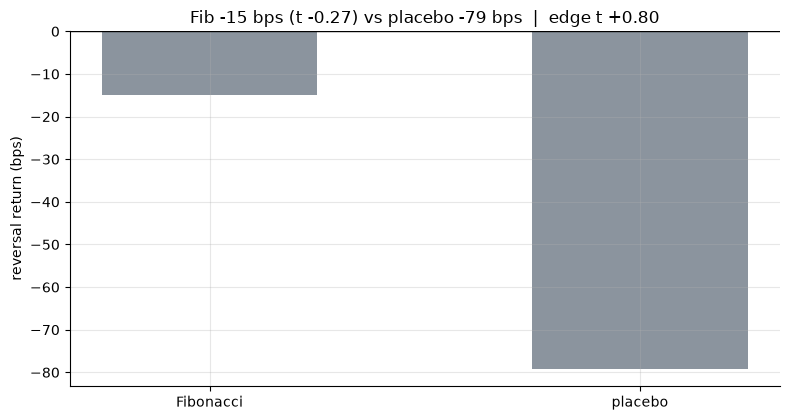

Fib n=225 -15 bps t -0.27 HAC -0.23 | plc n=197 -79 bps | edge +64 bps t +0.80


In [2]:
if HAVE_REAL:
    fa, pa = pooled_arms(TAPES)
    fib_bps, fib_t, fib_hac = fa.mean()*1e4, st.ttest_vs_zero(fa), st.hac_t(fa)
    plc_bps, plc_t = pa.mean()*1e4, st.ttest_vs_zero(pa)
    edge_bps, edge_t = (fa.mean()-pa.mean())*1e4, st.two_sample_t(fa, pa)
    nfib, nplc = len(fa), len(pa)
else:
    fib_bps, fib_t, fib_hac = -15.0, -0.27, -0.23
    plc_bps, plc_t = -79.2, -1.38
    edge_bps, edge_t = 64.2, 0.8
    nfib, nplc = 225, 197
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['Fibonacci', 'placebo'], [fib_bps, plc_bps], color=[GREY, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('reversal return (bps)')
ax.set_title(f'Fib {fib_bps:+.0f} bps (t {fib_t:+.2f}) vs placebo {plc_bps:+.0f} bps  |  edge t {edge_t:+.2f}')
plt.tight_layout(); plt.show()
print(f'Fib n={nfib} {fib_bps:+.0f} bps t {fib_t:+.2f} HAC {fib_hac:+.2f} | plc n={nplc} {plc_bps:+.0f} bps | edge {edge_bps:+.0f} bps t {edge_t:+.2f}')

> 💡 In plain words: **H\u2081 not rejected in the null direction** \u2014 the Fib arm earns -15 bps (*t* -0.27). **H\u2082 rejected** \u2014 the Fib\u2212placebo edge is only *t* 0.8. Fibonacci depths are not special.

### 4b \u00b7 Beats a coin? \u2014 H\u2084

Keep the same Fibonacci swing bars, randomise the direction with a fair coin many times: does the reversal bet beat the coin?

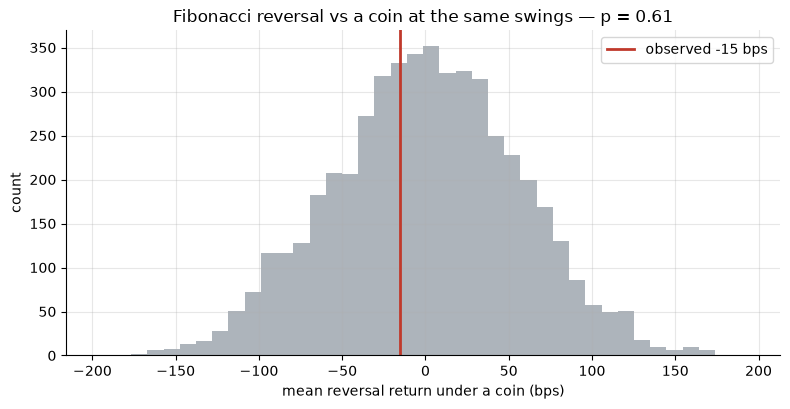

coin placebo p = 0.607


In [3]:
if HAVE_REAL:
    fa, _ = pooled_arms(TAPES)
    obs = fa.mean(); mags = np.abs(fa)
    rng = np.random.default_rng(541)
    draws = np.array([(rng.choice([-1,1], size=len(mags))*mags).mean() for _ in range(5000)])
    coin_p = float((draws >= obs).mean())
else:
    obs = -15.0/1e4; draws = np.random.default_rng(541).normal(0, abs(obs)+1e-4, 5000); coin_p = 0.61
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(draws*1e4, bins=40, color=GREY, alpha=.7)
ax.axvline(obs*1e4, c=RED, lw=2, label=f'observed {obs*1e4:+.0f} bps')
ax.set_xlabel('mean reversal return under a coin (bps)'); ax.set_ylabel('count')
ax.set_title(f'Fibonacci reversal vs a coin at the same swings \u2014 p = {coin_p:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'coin placebo p = {coin_p:.3f}')

> 💡 In plain words: **H\u2084 rejected** \u2014 the observed Fibonacci bounce sits in the fat middle of the coin distribution (*p* 0.61). The level adds no directional information over a coin placed at the identical swings.

### 4c \u00b7 Robustness \u2014 H\u2083 (does the (non-)edge hold?)

The Fib arm *t* and the Fib\u2212placebo edge *t* across the ZigZag\u00d7horizon grid.

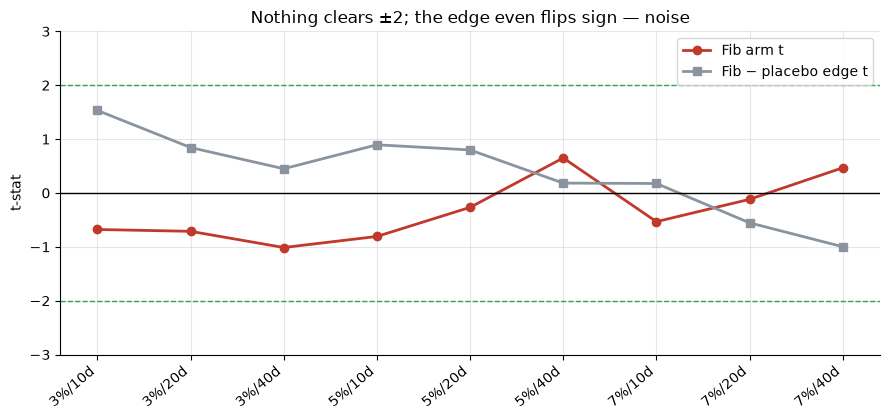

 zigzag  horizon  fib_n  fib_t  edge_t
   0.03       10    505  -0.68    1.53
   0.03       20    505  -0.71    0.84
   0.03       40    505  -1.01    0.45
   0.05       10    225  -0.81    0.89
   0.05       20    225  -0.27    0.80
   0.05       40    225   0.65    0.18
   0.07       10    139  -0.53    0.18
   0.07       20    139  -0.12   -0.55
   0.07       40    138   0.47   -1.00


In [4]:
grid = [(0.03, 10, 505, -0.68, 1.53), (0.03, 20, 505, -0.71, 0.84), (0.03, 40, 505, -1.01, 0.45), (0.05, 10, 225, -0.81, 0.89), (0.05, 20, 225, -0.27, 0.8), (0.05, 40, 225, 0.65, 0.18), (0.07, 10, 139, -0.53, 0.18), (0.07, 20, 139, -0.12, -0.55), (0.07, 40, 138, 0.47, -1.0)]
if HAVE_REAL:
    grid = []
    for pct in (0.03, 0.05, 0.07):
        for h in (10, 20, 40):
            fa, pa = pooled_arms(TAPES, pct=pct, horizon=h)
            grid.append((pct, h, len(fa), st.ttest_vs_zero(fa), st.two_sample_t(fa, pa)))
tab = pd.DataFrame(grid, columns=['zigzag','horizon','fib_n','fib_t','edge_t'])
fig, ax = plt.subplots(figsize=(9, 4.3))
x = range(len(tab)); labs = [f'{int(p*100)}%/{h}d' for p,h in zip(tab.zigzag, tab.horizon)]
ax.plot(x, tab.fib_t, 'o-', c=RED, lw=2, label='Fib arm t')
ax.plot(x, tab.edge_t, 's-', c=GREY, lw=2, label='Fib \u2212 placebo edge t')
ax.axhline(2, ls='--', c=GREEN, lw=1); ax.axhline(-2, ls='--', c=GREEN, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels(labs, rotation=40, ha='right')
ax.set_ylabel('t-stat'); ax.set_ylim(-3, 3)
ax.set_title('Nothing clears \u00b12; the edge even flips sign \u2014 noise')
ax.legend(); plt.tight_layout(); plt.show()
print(tab.round(2).to_string(index=False))

> 💡 In plain words: **H\u2083 rejected.** No cell of the grid clears |*t*| = 2, the Fib arm is flat-to-negative throughout, and the Fib\u2212placebo edge wanders from +1.53 to \u22121.00 \u2014 the sign isn't even stable. That is exactly what a non-effect looks like.

## 5 · The verdict

- **Signal `NONE`** \u2014 H\u2081 null (Fib arm *t* -0.27); H\u2082 rejected (edge *t* 0.8); H\u2083 rejected (sign flips); H\u2084 rejected (coin *p* 0.61).
- **Tradability `MIRAGE`** \u2014 gross -15 bps \u2192 net -17 bps; per-tape edge is pure scatter.
- **Fib levels special? `NOT SUPPORTED`** \u2014 arbitrary fractions match; the engine would catch a real level-effect (next beat).

## 6 · Could you trade it? \u2014 costs and the per-tape scatter

There's no edge to charge costs against, and the per-tape results are noise.

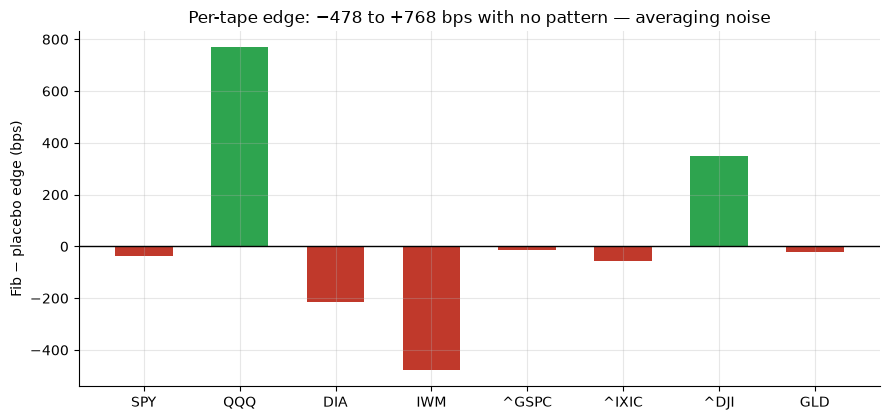

 tape  fib_n  fib_bps  edge_bps
  SPY     22    -24.0     -36.0
  QQQ     24    442.0     768.0
  DIA     21   -108.0    -215.0
  IWM     19   -228.0    -478.0
^GSPC     62    -69.0     -15.0
^IXIC     47   -107.0     -55.0
 ^DJI     20    273.0     347.0
  GLD     10   -301.0     -21.0


In [5]:
per = [('SPY', 22, -24, -36), ('QQQ', 24, 442, 768), ('DIA', 21, -108, -215), ('IWM', 19, -228, -478), ('^GSPC', 62, -69, -15), ('^IXIC', 47, -107, -55), ('^DJI', 20, 273, 347), ('GLD', 10, -301, -21)]
if HAVE_REAL:
    per = []
    for tk, b in TAPES.items():
        close = b['close'].to_numpy(float); piv = st.zigzag(close, PCT); rd = st.swing_retracements(piv)
        lf = st.run_trades(close, st.bin_touches(rd, data.FIB_LEVELS, TOL), HORIZON, 0.0)
        lp = st.run_trades(close, st.bin_touches(rd, data.PLACEBO_LEVELS, TOL), HORIZON, 0.0)
        fb = lf['ret_gross'].mean()*1e4 if len(lf) else np.nan
        eb = (lf['ret_gross'].mean()-lp['ret_gross'].mean())*1e4 if len(lf) and len(lp) else np.nan
        per.append((tk, len(lf), fb, eb))
tab = pd.DataFrame(per, columns=['tape','fib_n','fib_bps','edge_bps'])
fig, ax = plt.subplots(figsize=(9, 4.3))
cols = [GREEN if e>0 else RED for e in tab.edge_bps]
ax.bar(tab.tape, tab.edge_bps, color=cols, width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Fib \u2212 placebo edge (bps)')
ax.set_title('Per-tape edge: \u2212478 to +768 bps with no pattern \u2014 averaging noise')
plt.tight_layout(); plt.show()
print(tab.round(0).to_string(index=False))

> 💡 In plain words: the pooled +64 bps edge is a small average of large cancelling per-tape numbers (IWM \u2212478, QQQ +768). Add a 1 bp/side spread and the Fibonacci bet goes from -15 bps to -17 bps net. `MIRAGE`.

## 7 · Going further \u2014 the synthetic controls

Is the engine a faithful detector, or would it miss a real level-effect? Two controls. **(a)** A clean swing panel where swings that retrace to a Fibonacci depth are *given* an extra forward return `fib_pull`; the binning + two-sample test must recover it, averaged over 25 seeds so no lucky seed can fake it. **(b)** The whole pipeline on a genuine random-swing price path with no planted effect must stay flat.

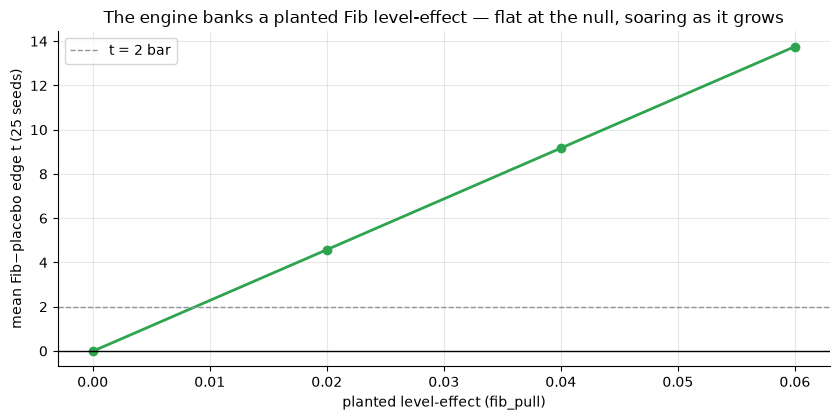

fib_pull +0.00 -> mean edge t -0.01
fib_pull +0.02 -> mean edge t +4.58
fib_pull +0.04 -> mean edge t +9.17
fib_pull +0.06 -> mean edge t +13.76


price-path NULL mean edge t (10 seeds): -0.02


In [6]:
ctrl = [(0.0, -0.01), (0.02, 4.58), (0.04, 9.17), (0.06, 13.76)]
if True:  # deterministic, offline, fast
    pulls = [0.0, 0.02, 0.04, 0.06]
    ctrl = [(p, st.synthetic_control(data, fib_pull=p, n_seeds=25)['mean_edge_t']) for p in pulls]
xs = [c[0] for c in ctrl]; ts = [c[1] for c in ctrl]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(xs, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar'); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted level-effect (fib_pull)'); ax.set_ylabel('mean Fib\u2212placebo edge t (25 seeds)')
ax.set_title('The engine banks a planted Fib level-effect \u2014 flat at the null, soaring as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for p, t in ctrl: print(f'fib_pull {p:+.2f} -> mean edge t {t:+.2f}')
# (b) genuine price-path null: pipeline must find no false edge
null_ed = []
for s in range(541, 551):
    bars, _ = data.synthetic_tape(n_swings=1200, fib_pull=0.0, seed=s)
    r = st.run_experiment(bars, horizon=20, cost_bps=0.0, coin_draws=1, seed=s)
    null_ed.append(r['edge_t'])
print(f'price-path NULL mean edge t (10 seeds): {np.mean(null_ed):+.2f}')

At the null both controls sit at \u2248 0 (edge *t* \u22120.01 on the swing panel, -0.02 on the price path); a planted Fibonacci level-effect drives the edge *t* to +4.6 / +9.2 / +13.8 as it grows. **The detector is faithful** \u2014 so the real-tape null is a statement about the tape, not a broken test. For the wave-count version of the Fibonacci story, see [445 Elliott Wave](../../445-elliott-wave/); for round *price* levels, [93 Round Numbers](../../93-round-numbers/).